In [7]:
!pip install kaggle

In [8]:
!pip install category_encoders

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import category_encoders as ce

In [10]:
!kaggle datasets download -d gregorut/videogamesales

Dataset URL: https://www.kaggle.com/datasets/gregorut/videogamesales
License(s): unknown
videogamesales.zip: Skipping, found more recently modified local copy (use --force to force download)


In [11]:
import zipfile
import pandas as pd

with zipfile.ZipFile('videogamesales.zip', 'r') as zip_ref:
    zip_ref.extractall('./videogame_data')

df = pd.read_csv('./videogame_data/vgsales.csv')

In [12]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [13]:
df.tail()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.0,0.0,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.0,0.0,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.0,0.0,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.0,0.0,0.01
16597,16600,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.00,0.0,0.0,0.01


In [14]:
df.shape

(16598, 11)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [16]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [17]:
df.describe(include="object")

,Name,Platform,Genre,Publisher
count,16598,16598,16598,16540
unique,11493,31,12,578
top,Need for Speed: Most Wanted,DS,Action,Electronic Arts
freq,12,2163,3316,1351


In [18]:
df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.dtypes

Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

In [21]:
df_droped = df.dropna() # Если пропусков мало < 5-10%
df_droped

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [22]:
df_mean = df.copy()
mean_year = df_mean['Year'].mean()
df_mean['Year'] = df_mean['Year'].fillna(mean_year) # Среднее арифметическое хорошо работает для числовых признаков с примерно симметричным распределением без сильных выбросов.
df_mean

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [23]:
df_median = df.copy()
median_year = df_median['Year'].median()
df_median['Year'] = df_median['Year'].fillna(median_year) # Медиана устойчива к выбросам.
df_median

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [24]:
df_const = df.copy()
df_const['Year'] = df_const['Year'].fillna(0) # Иногда пропуск сам по себе несёт смысл.
df_const

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [25]:
df_mode = df.copy()
mode_publisher = df_mode['Publisher'].mode()[0]
df_mode['Publisher'] = df_mode['Publisher'].fillna(mode_publisher)
df_mode

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [26]:
num_cols = ['Year', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

stats = {}
for col in num_cols:
    min_val = df[col].min()
    max_val = df[col].max()
    mean_val = df[col].mean()
    median_val = df[col].median()
    mode_val = df[col].mode()[0] if not df[col].mode().empty else np.nan

    stats[col] = {
        'min': min_val,
        'max': max_val,
        'mean': mean_val,
        'median': median_val,
        'mode': mode_val
    }

stats_df = pd.DataFrame(stats).T
stats_df

,min,max,mean,median,mode
Year,1980.00,2020.00,2006.406443,2007.00,2009.00
NA_Sales,0.00,41.49,0.264667,0.08,0.00
EU_Sales,0.00,29.02,0.146652,0.02,0.00
JP_Sales,0.00,10.22,0.077782,0.00,0.00
Other_Sales,0.00,10.57,0.048063,0.01,0.00
Global_Sales,0.01,82.74,0.537441,0.17,0.02


In [27]:
percentiles = [0.05, 0.25, 0.5, 0.75, 0.95]
df[num_cols].quantile(percentiles)

,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0.05,1996.0,0.00,0.00,0.00,0.00,0.02
0.25,2003.0,0.00,0.00,0.00,0.00,0.06
0.50,2007.0,0.08,0.02,0.00,0.01,0.17
0.75,2010.0,0.24,0.11,0.04,0.04,0.47
0.95,2015.0,1.06,0.63,0.36,0.20,2.04


In [28]:
df[num_cols].var() # Year - 34(разброс годов по нескольким десятилетиям), NA_Sales >> JP_Sales => Разброс продаж в америке намного больше чем в Японии

Year            33.977021
NA_Sales         0.666971
EU_Sales         0.255380
JP_Sales         0.095661
Other_Sales      0.035566
Global_Sales     2.418112
dtype: float64

In [29]:
df[num_cols].skew() # Распределение годов смещено влево, все показатели продаж имеют сильную положительную асимметрию.

Year            -1.002560
NA_Sales        18.799627
EU_Sales        18.875535
JP_Sales        11.206458
Other_Sales     24.233923
Global_Sales    17.400645
dtype: float64

In [30]:
df[num_cols].kurtosis() # Большинство игр сконцентрировано в области низких продаж

Year               1.848181
NA_Sales         649.130268
EU_Sales         756.027796
JP_Sales         194.233994
Other_Sales     1025.348145
Global_Sales     603.932346
dtype: float64

In [31]:
cat_cols_ohe = ['Platform', 'Genre']
df_ohe = pd.get_dummies(df, columns=cat_cols_ohe, prefix=cat_cols_ohe)
df_ohe

,Rank,Name,Year,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Platform_2600,...,Genre_Fighting,Genre_Misc,Genre_Platform,Genre_Puzzle,Genre_Racing,Genre_Role-Playing,Genre_Shooter,Genre_Simulation,Genre_Sports,Genre_Strategy
0,1,Wii Sports,2006.0,Nintendo,41.49,29.02,3.77,8.46,82.74,False,...,False,False,False,False,False,False,False,False,True,False
1,2,Super Mario Bros.,1985.0,Nintendo,29.08,3.58,6.81,0.77,40.24,False,...,False,False,True,False,False,False,False,False,False,False
2,3,Mario Kart Wii,2008.0,Nintendo,15.85,12.88,3.79,3.31,35.82,False,...,False,False,False,False,True,False,False,False,False,False
3,4,Wii Sports Resort,2009.0,Nintendo,15.75,11.01,3.28,2.96,33.00,False,...,False,False,False,False,False,False,False,False,True,False
4,5,Pokemon Red/Pokemon Blue,1996.0,Nintendo,11.27,8.89,10.22,1.00,31.37,False,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,2002.0,Kemco,0.01,0.00,0.00,0.00,0.01,False,...,False,False,True,False,False,False,False,False,False,False
16594,16597,Men in Black II: Alien Escape,2003.0,Infogrames,0.01,0.00,0.00,0.00,0.01,False,...,False,False,False,False,False,False,True,False,False,False
16595,16598,SCORE International Baja 1000: The Official Game,2008.0,Activision,0.00,0.00,0.00,0.00,0.01,False,...,False,False,False,False,True,False,False,False,False,False
16596,16599,Know How 2,2010.0,7G//AMES,0.00,0.01,0.00,0.00,0.01,False,...,False,False,False,True,False,False,False,False,False,False


In [32]:
df_label = df.copy()
le = LabelEncoder()
df_label['Publisher_Label'] = le.fit_transform(df_label['Publisher'])
df_label[['Publisher', 'Publisher_Label']].head(10)

,Publisher,Publisher_Label
0,Nintendo,359
1,Nintendo,359
2,Nintendo,359
3,Nintendo,359
4,Nintendo,359
5,Nintendo,359
6,Nintendo,359
7,Nintendo,359
8,Nintendo,359
9,Nintendo,359


In [33]:
te = ce.TargetEncoder(cols=['Publisher'])
df_target = df.copy()
df_target['Publisher_Target'] = te.fit_transform(df['Publisher'], df['Global_Sales'])
df_target[['Publisher', 'Global_Sales', 'Publisher_Target']].head(10)

,Publisher,Global_Sales,Publisher_Target
0,Nintendo,82.74,2.541337
1,Nintendo,40.24,2.541337
2,Nintendo,35.82,2.541337
3,Nintendo,33.00,2.541337
4,Nintendo,31.37,2.541337
5,Nintendo,30.26,2.541337
6,Nintendo,30.01,2.541337
7,Nintendo,29.02,2.541337
8,Nintendo,28.62,2.541337
9,Nintendo,28.31,2.541337


In [34]:
he = ce.HashingEncoder(cols=['Publisher'], n_components=100)
df_hash = he.fit_transform(df['Publisher'])
df_hash = pd.concat([df[['Platform', 'Genre', 'Year', 'Global_Sales']], df_hash], axis=1)
df_hash.head()

,Platform,Genre,Year,Global_Sales,col_0,col_1,col_2,col_3,col_4,col_5,...,col_90,col_91,col_92,col_93,col_94,col_95,col_96,col_97,col_98,col_99
0,Wii,Sports,2006.0,82.74,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,NES,Platform,1985.0,40.24,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Wii,Racing,2008.0,35.82,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Wii,Sports,2009.0,33.00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,GB,Role-Playing,1996.0,31.37,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [35]:
df_feat = df.copy()
df_feat['NA_Ratio'] = df_feat['NA_Sales'] / df_feat['Global_Sales'].replace(0, np.nan)
df_feat['EU_Ratio'] = df_feat['EU_Sales'] / df_feat['Global_Sales'].replace(0, np.nan)
df_feat['JP_Ratio'] = df_feat['JP_Sales'] / df_feat['Global_Sales'].replace(0, np.nan)
df_feat['Other_Ratio'] = df_feat['Other_Sales'] / df_feat['Global_Sales'].replace(0, np.nan)
df_feat[['NA_Ratio', 'EU_Ratio', 'JP_Ratio', 'Other_Ratio']] = df_feat[['NA_Ratio', 'EU_Ratio', 'JP_Ratio', 'Other_Ratio']].fillna(0)
df_feat[['Name', 'NA_Ratio', 'EU_Ratio', 'JP_Ratio', 'Other_Ratio']].head()

,Name,NA_Ratio,EU_Ratio,JP_Ratio,Other_Ratio
0,Wii Sports,0.501450,0.350737,0.045564,0.102248
1,Super Mario Bros.,0.722664,0.088966,0.169235,0.019135
2,Mario Kart Wii,0.442490,0.359576,0.105807,0.092406
3,Wii Sports Resort,0.477273,0.333636,0.099394,0.089697
4,Pokemon Red/Pokemon Blue,0.359260,0.283392,0.325789,0.031878


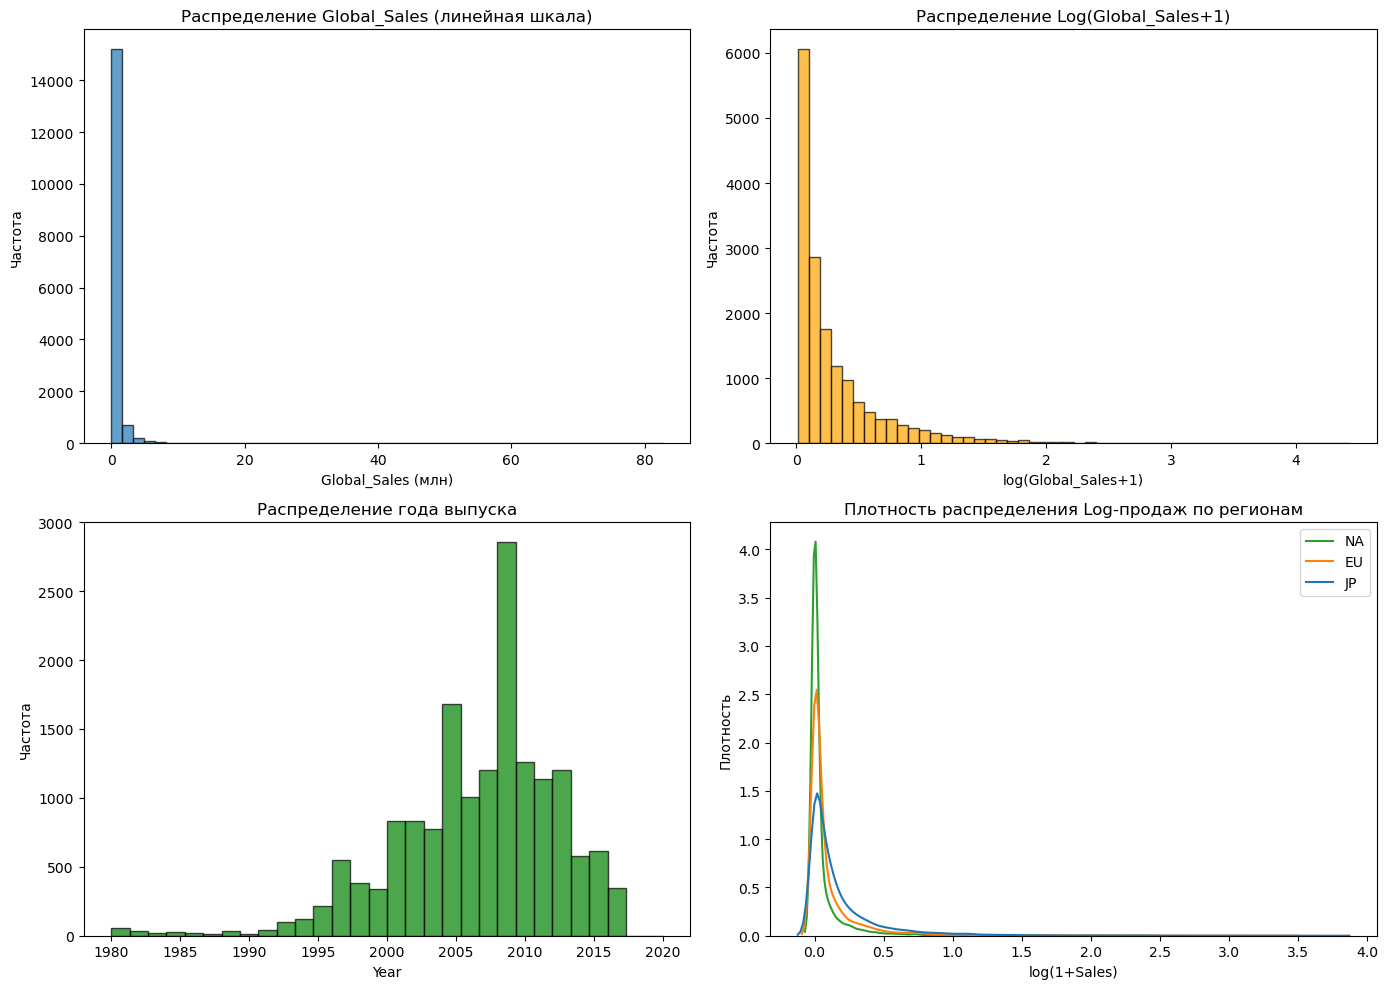

In [40]:
df_clean = df.dropna(subset=['Year', 'Publisher']).copy()
df_clean['Year'] = df_clean['Year'].astype(int)

for col in ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']:
    df_clean[f'Log_{col}'] = np.log1p(df_clean[col])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].hist(df_clean['Global_Sales'], bins=50, edgecolor='black', alpha=0.7)
axes[0,0].set_title('Распределение Global_Sales (линейная шкала)')
axes[0,0].set_xlabel('Global_Sales (млн)')
axes[0,0].set_ylabel('Частота')

axes[0,1].hist(df_clean['Log_Global_Sales'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0,1].set_title('Распределение Log(Global_Sales+1)')
axes[0,1].set_xlabel('log(Global_Sales+1)')
axes[0,1].set_ylabel('Частота')

axes[1,0].hist(df_clean['Year'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1,0].set_title('Распределение года выпуска')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('Частота')

sns.kdeplot(data=df_clean[['Log_NA_Sales', 'Log_EU_Sales', 'Log_JP_Sales']], ax=axes[1,1])
axes[1,1].set_title('Плотность распределения Log-продаж по регионам')
axes[1,1].set_xlabel('log(1+Sales)')
axes[1,1].set_ylabel('Плотность')
axes[1,1].legend(['NA', 'EU', 'JP'])

plt.tight_layout()
plt.show()

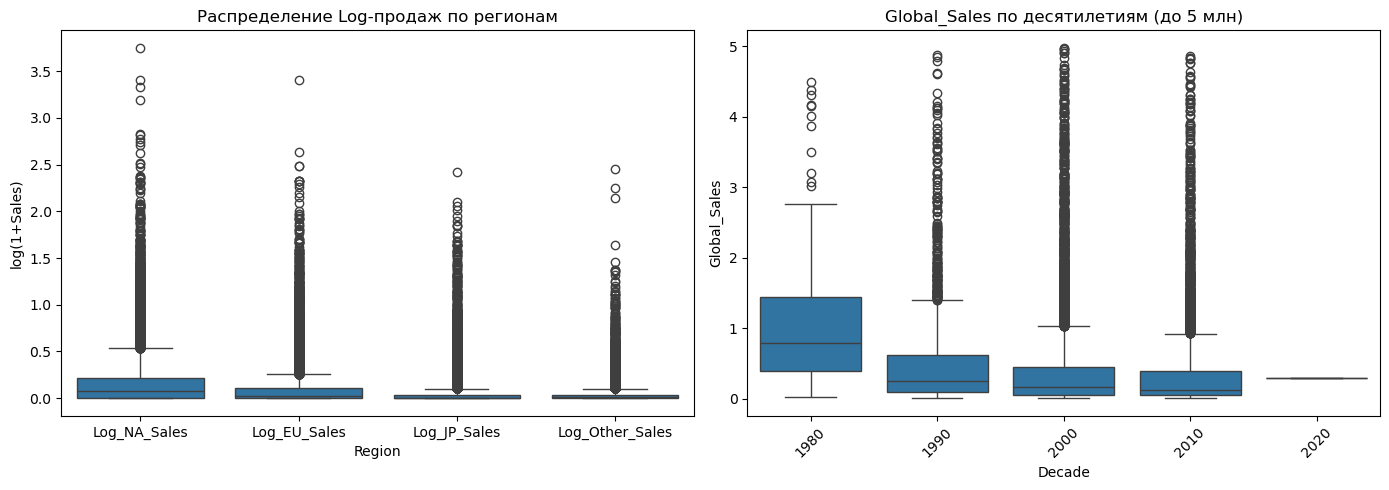

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_melted = df_clean[['Log_NA_Sales', 'Log_EU_Sales', 'Log_JP_Sales', 'Log_Other_Sales']].melt(var_name='Region', value_name='Log_Sales')
sns.boxplot(data=df_melted, x='Region', y='Log_Sales', ax=axes[0])
axes[0].set_title('Распределение Log-продаж по регионам')
axes[0].set_ylabel('log(1+Sales)')

df_clean['Decade'] = (df_clean['Year'] // 10) * 10
sns.boxplot(data=df_clean[df_clean['Global_Sales']<5], x='Decade', y='Global_Sales', ax=axes[1])
axes[1].set_title('Global_Sales по десятилетиям (до 5 млн)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

/var/folders/xk/wlrlm1bs56948lpflppf_k_r0000gn/T/ipykernel_5509/2791272203.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_platforms.values, y=top_platforms.index, ax=axes[0,0], palette='viridis')
/var/folders/xk/wlrlm1bs56948lpflppf_k_r0000gn/T/ipykernel_5509/2791272203.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[0,1], palette='magma')
/var/folders/xk/wlrlm1bs56948lpflppf_k_r0000gn/T/ipykernel_5509/2791272203.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_publish

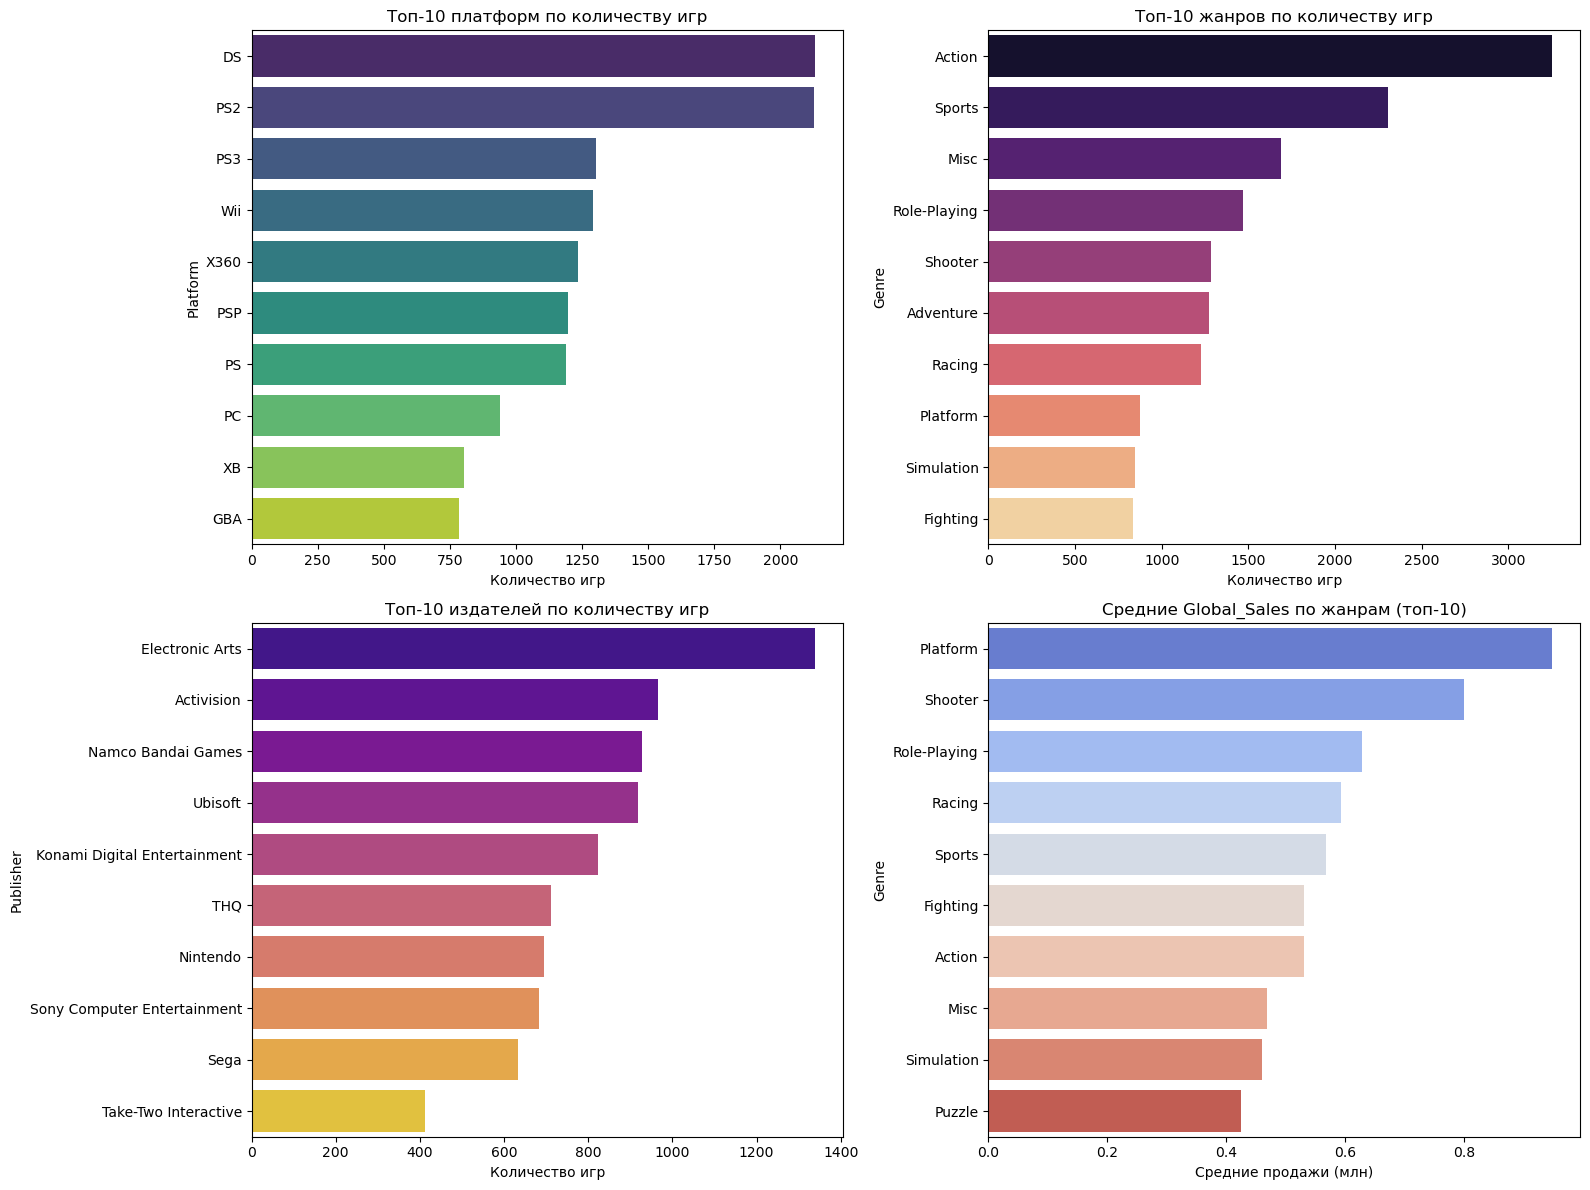

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

top_platforms = df_clean['Platform'].value_counts().head(10)
sns.barplot(x=top_platforms.values, y=top_platforms.index, ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Топ-10 платформ по количеству игр')
axes[0,0].set_xlabel('Количество игр')

top_genres = df_clean['Genre'].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[0,1], palette='magma')
axes[0,1].set_title('Топ-10 жанров по количеству игр')
axes[0,1].set_xlabel('Количество игр')

top_publishers = df_clean['Publisher'].value_counts().head(10)
sns.barplot(x=top_publishers.values, y=top_publishers.index, ax=axes[1,0], palette='plasma')
axes[1,0].set_title('Топ-10 издателей по количеству игр')
axes[1,0].set_xlabel('Количество игр')

genre_means = df_clean.groupby('Genre')['Global_Sales'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=genre_means.values, y=genre_means.index, ax=axes[1,1], palette='coolwarm')
axes[1,1].set_title('Средние Global_Sales по жанрам (топ-10)')
axes[1,1].set_xlabel('Средние продажи (млн)')

plt.tight_layout()
plt.show()

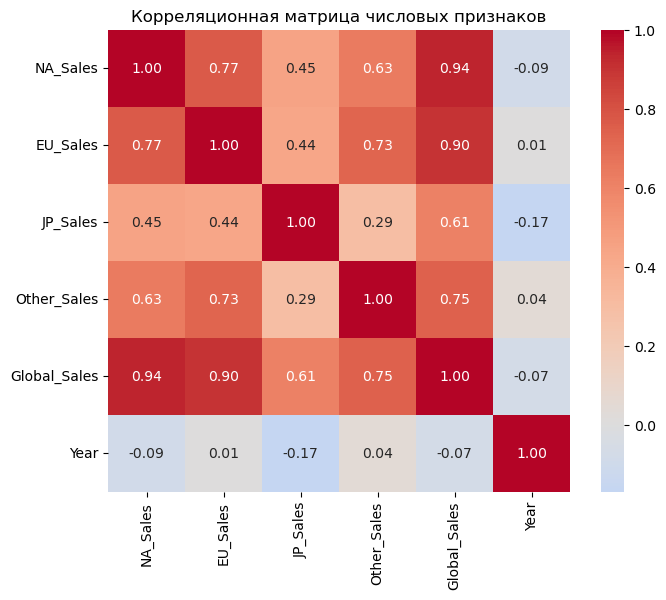

In [51]:
corr_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Year']
corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Корреляционная матрица числовых признаков')
plt.show()

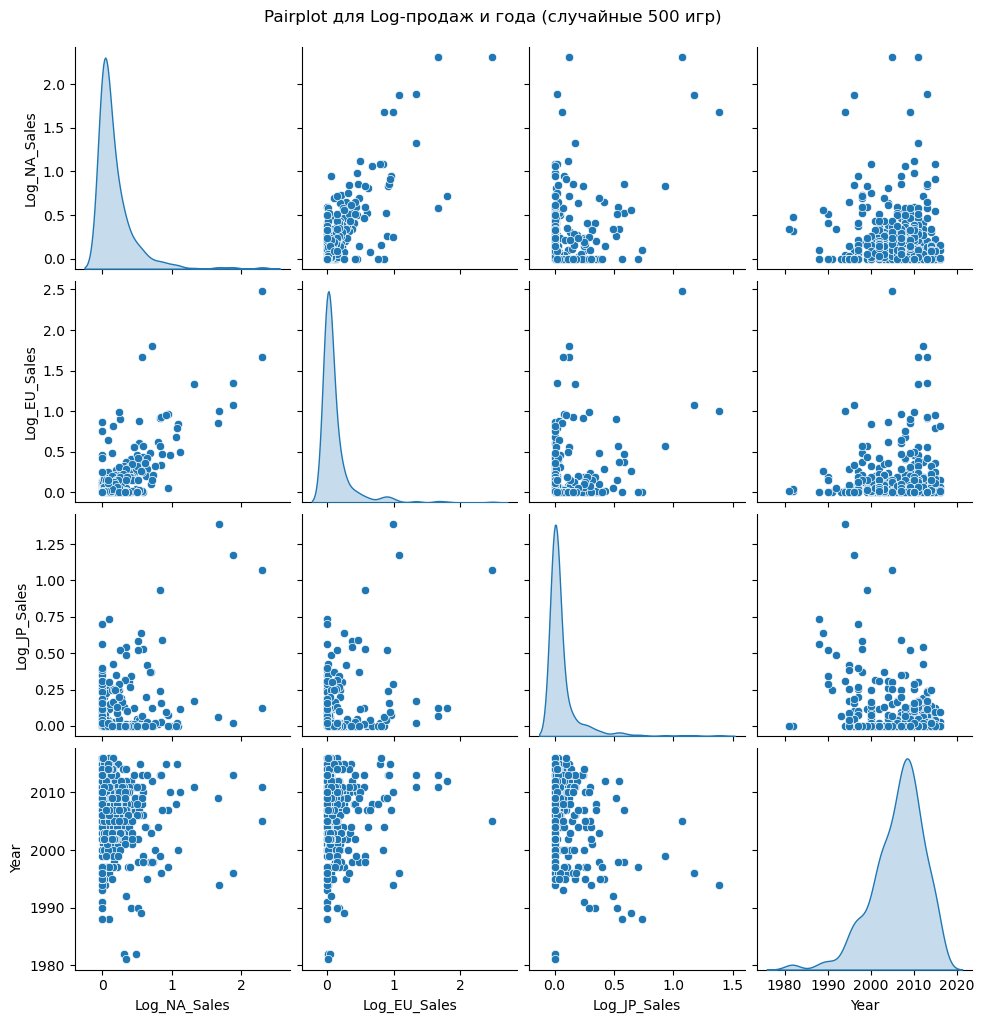

In [52]:
sns.pairplot(df_clean[['Log_NA_Sales', 'Log_EU_Sales', 'Log_JP_Sales', 'Year']].sample(500), diag_kind='kde')
plt.suptitle('Pairplot для Log-продаж и года (случайные 500 игр)', y=1.02)
plt.show()

/var/folders/xk/wlrlm1bs56948lpflppf_k_r0000gn/T/ipykernel_5509/2115973035.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_violin, x='Genre', y='Global_Sales', scale='width', palette='muted')
/var/folders/xk/wlrlm1bs56948lpflppf_k_r0000gn/T/ipykernel_5509/2115973035.py:4: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=df_violin, x='Genre', y='Global_Sales', scale='width', palette='muted')


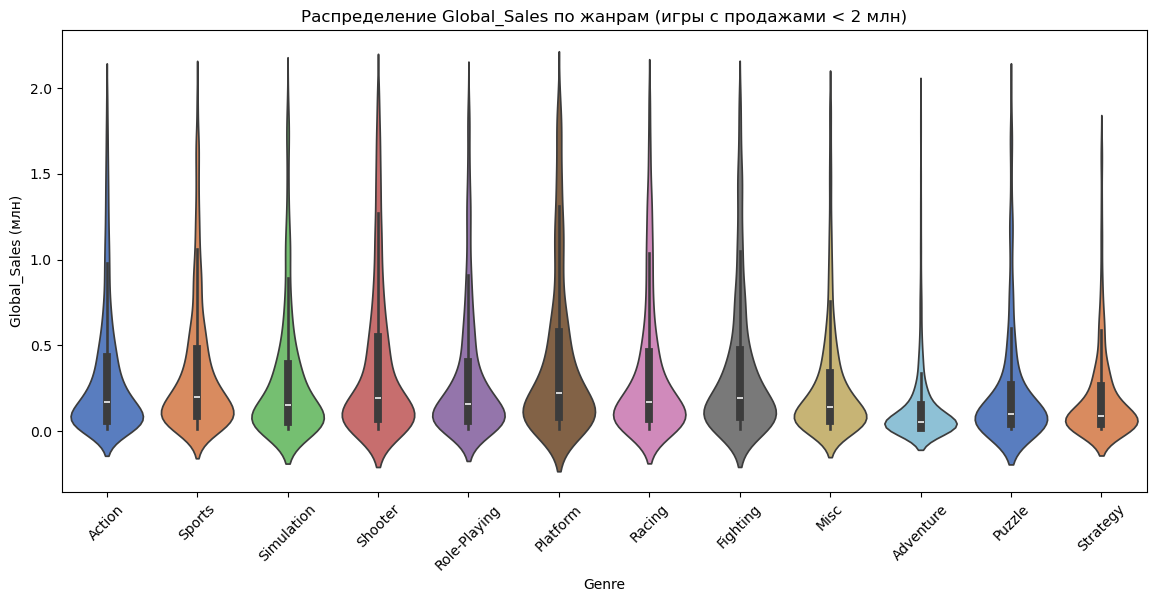

In [53]:
plt.figure(figsize=(14,6))

df_violin = df_clean[df_clean['Global_Sales'] < 2]
sns.violinplot(data=df_violin, x='Genre', y='Global_Sales', scale='width', palette='muted')
plt.xticks(rotation=45)
plt.title('Распределение Global_Sales по жанрам (игры с продажами < 2 млн)')
plt.ylabel('Global_Sales (млн)')
plt.show()

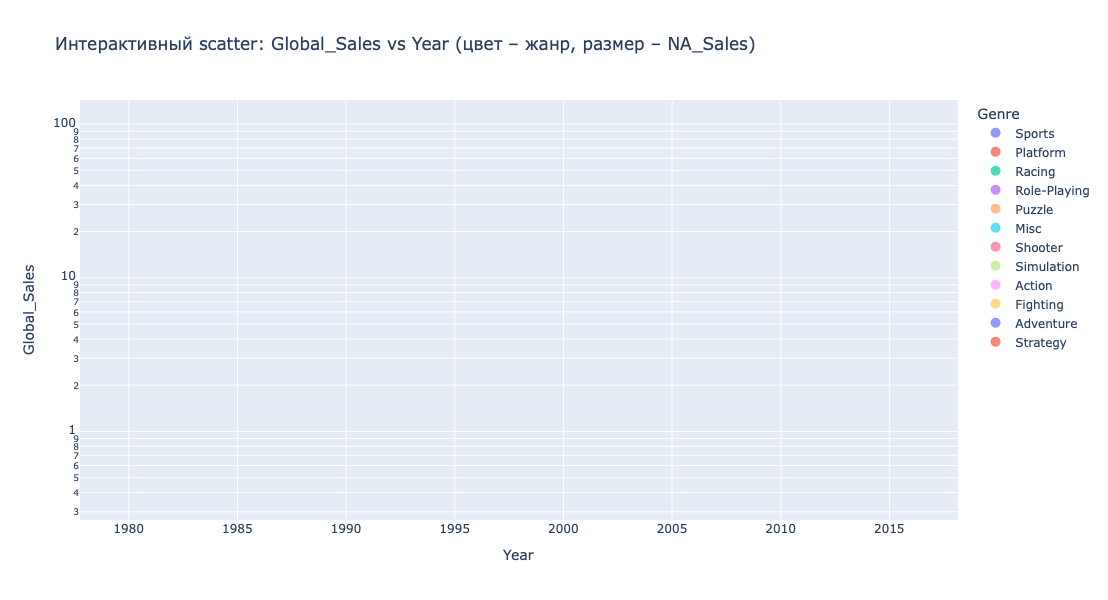

In [54]:
df_plotly = df_clean.nlargest(5000, 'Global_Sales')

fig = px.scatter(df_plotly, 
                 x='Year', 
                 y='Global_Sales', 
                 color='Genre',
                 size='NA_Sales',
                 hover_data=['Name', 'Platform', 'Publisher', 'EU_Sales', 'JP_Sales'],
                 title='Интерактивный scatter: Global_Sales vs Year (цвет – жанр, размер – NA_Sales)',
                 log_y=True, 
                 width=1000,
                 height=600)

fig.update_layout(legend=dict(itemsizing='constant'))
fig.show()

# Выводы

## Что я понял про датасет

- Датасет содержит **16 598 игр** с продажами по 4 регионам (NA, EU, JP, Other) за период **1980–2020**, основная масса приходится на 2000–2015 годы.
- Распределение продаж **крайне скошено вправо** (skewness ≈ 17–24): подавляющее большинство игр продаётся плохо, а единичные хиты формируют длинный правый хвост. Медиана Global_Sales — всего **0.17 млн** при среднем **0.54 млн**.
- **Северная Америка** — доминирующий рынок: средние NA_Sales почти вдвое больше EU_Sales и втрое больше JP_Sales. При этом NA_Sales и EU_Sales сильно коррелируют между собой, а JP_Sales ведёт себя заметно иначе (слабая корреляция с остальными регионами).
- Самые **массовые платформы** по числу релизов — DS, PS2, PS3, Wii, X360; самые **массовые жанры** — Action, Sports, Misc, Role-Playing.
- По **средним продажам** лидируют жанры Platform, Shooter и Sports — то есть массовость жанра и его коммерческая успешность не совпадают (Action — самый частый, но не самый прибыльный).
- **Пропуски** минимальны: 271 запись без года (1.6%) и 58 без издателя (0.35%), что позволяет без большого ущерба удалить их или заполнить медианой/модой.
- **Выбросы** — это реальные мега-хиты (Wii Sports — 82.74 млн, Super Mario Bros. — 40.24 млн). Эксцесс столбцов продаж огромный (600–1000+), что подтверждает тяжёлые хвосты.
- Логарифмическое преобразование `log(1 + Sales)` хорошо нормализует распределение продаж и делает данные более пригодными для линейных моделей.
- **Nintendo** — безусловный лидер и как издатель (по средним продажам на игру), и как владелец платформ с играми-рекордсменами.
- Столбец `Rank` — это просто порядковый номер по Global_Sales, он полностью избыточен и не несёт дополнительной информации.
- Год выпуска слабо коррелирует с продажами (корреляция ≈ −0.1), но важен для понимания трендов индустрии.

## Гипотезы и наблюдения

1. **Жанр и платформа — главные категориальные предикторы продаж.** Средние продажи по жанрам различаются в разы (Platform/Shooter vs Strategy/Puzzle). Вероятно, OHE-жанр + OHE-платформа дадут значимый прирост качества модели по сравнению с использованием только числовых признаков.

2. **Японский рынок принципиально отличается от западного.** JP_Sales слабо коррелирует с NA/EU. Гипотеза: жанр Role-Playing непропорционально популярен в Японии, а жанры Shooter/Sports — в Америке. Это значит, что для предсказания региональных продаж нужны отдельные модели или явные interaction-фичи «жанр × регион».

3. **Выбросы — не шум, а хиты определённого профиля.** Мега-хиты (Global_Sales > 20 млн) почти все принадлежат Nintendo и относятся к жанрам Sports/Platform. Это не случайные аномалии, а закономерность: first-party игры Nintendo на собственных консолях продаются на порядок лучше. Удалять их нельзя — лучше использовать log-преобразование таргета.

4. **Publisher сильно влияет на продажи, но кардинальность высокая (578 уникальных).** Target Encoding по Publisher даёт осмысленные значения (Nintendo ≈ 2.5 vs мелкие паблишеры ≈ 0.1), но при наивном использовании на всём датасете возникает data leakage. Для модели стоит применять Target Encoding строго внутри кросс-валидации.

5. **Доля региональных продаж (NA_Ratio, JP_Ratio) — потенциально сильная фича** для задач классификации (например, предсказание жанра или региона-лидера по продажам). Игры с JP_Ratio > 0.5 почти наверняка Role-Playing или Fighting.

## Что делать дальше

- **Задача регрессии:** предсказывать `log(1 + Global_Sales)` по признакам Year, Genre (OHE), Platform (OHE), Publisher (Target Encoding в CV).
- **Базовая модель:** начать с **Ridge / Lasso** на log-таргете, чтобы иметь линейный бейзлайн. Затем попробовать **Random Forest** и **Gradient Boosting (LightGBM/CatBoost)** — они хорошо работают со смешанными типами фичей и не требуют нормализации.
- **Фичи для модели:** Year, Genre (OHE), Platform (OHE), Publisher (Target Encoding или группировка в «top-20 + Other»), а также сгенерированные NA_Ratio / EU_Ratio / JP_Ratio, если таргет — региональные продажи.
- **Валидация:** использовать TimeSeriesSplit или стратифицированный KFold, чтобы не допускать утечки из будущих лет в прошлые.
- **Альтернативная задача классификации:** бинарная — «хит или нет» (Global_Sales > 1 млн), что полезнее с практической точки зрения, так как точное предсказание продаж затруднено из-за огромной дисперсии.

## Какие подсказки брал у AI и что проверял/дописывал руками

- **AI помог** подобрать способы кодирования категориальных признаков (Target Encoding, Hashing Encoder) — подсказал библиотеку `category_encoders` и примеры использования
- **Руками делал** все остальное